In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [4]:

df=pd.read_csv('insurance_claims.csv')

In [5]:
print(df.head(10))

   months_as_customer  age  policy_number policy_bind_date policy_state  \
0                 328   48         521585       2014-10-17           OH   
1                 228   42         342868       2006-06-27           IN   
2                 134   29         687698       2000-09-06           OH   
3                 256   41         227811       1990-05-25           IL   
4                 228   44         367455       2014-06-06           IL   
5                 256   39         104594       2006-10-12           OH   
6                 137   34         413978       2000-06-04           IN   
7                 165   37         429027       1990-02-03           IL   
8                  27   33         485665       1997-02-05           IL   
9                 212   42         636550       2011-07-25           IL   

  policy_csl  policy_deductable  policy_annual_premium  umbrella_limit  \
0    250/500               1000                1406.91               0   
1    250/500              

In [6]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [7]:
df.shape

(1000, 40)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [9]:
df.replace('?', np.nan, inplace = True)

In [10]:
df.shape

(1000, 40)

In [11]:
#missing values
df.isnull().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                  178
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

In [12]:
df['authorities_contacted'] = df['authorities_contacted'].fillna(df['authorities_contacted'].mode()[0])

In [13]:
df.isna().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                  178
incident_severity                 0
authorities_contacted             0
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

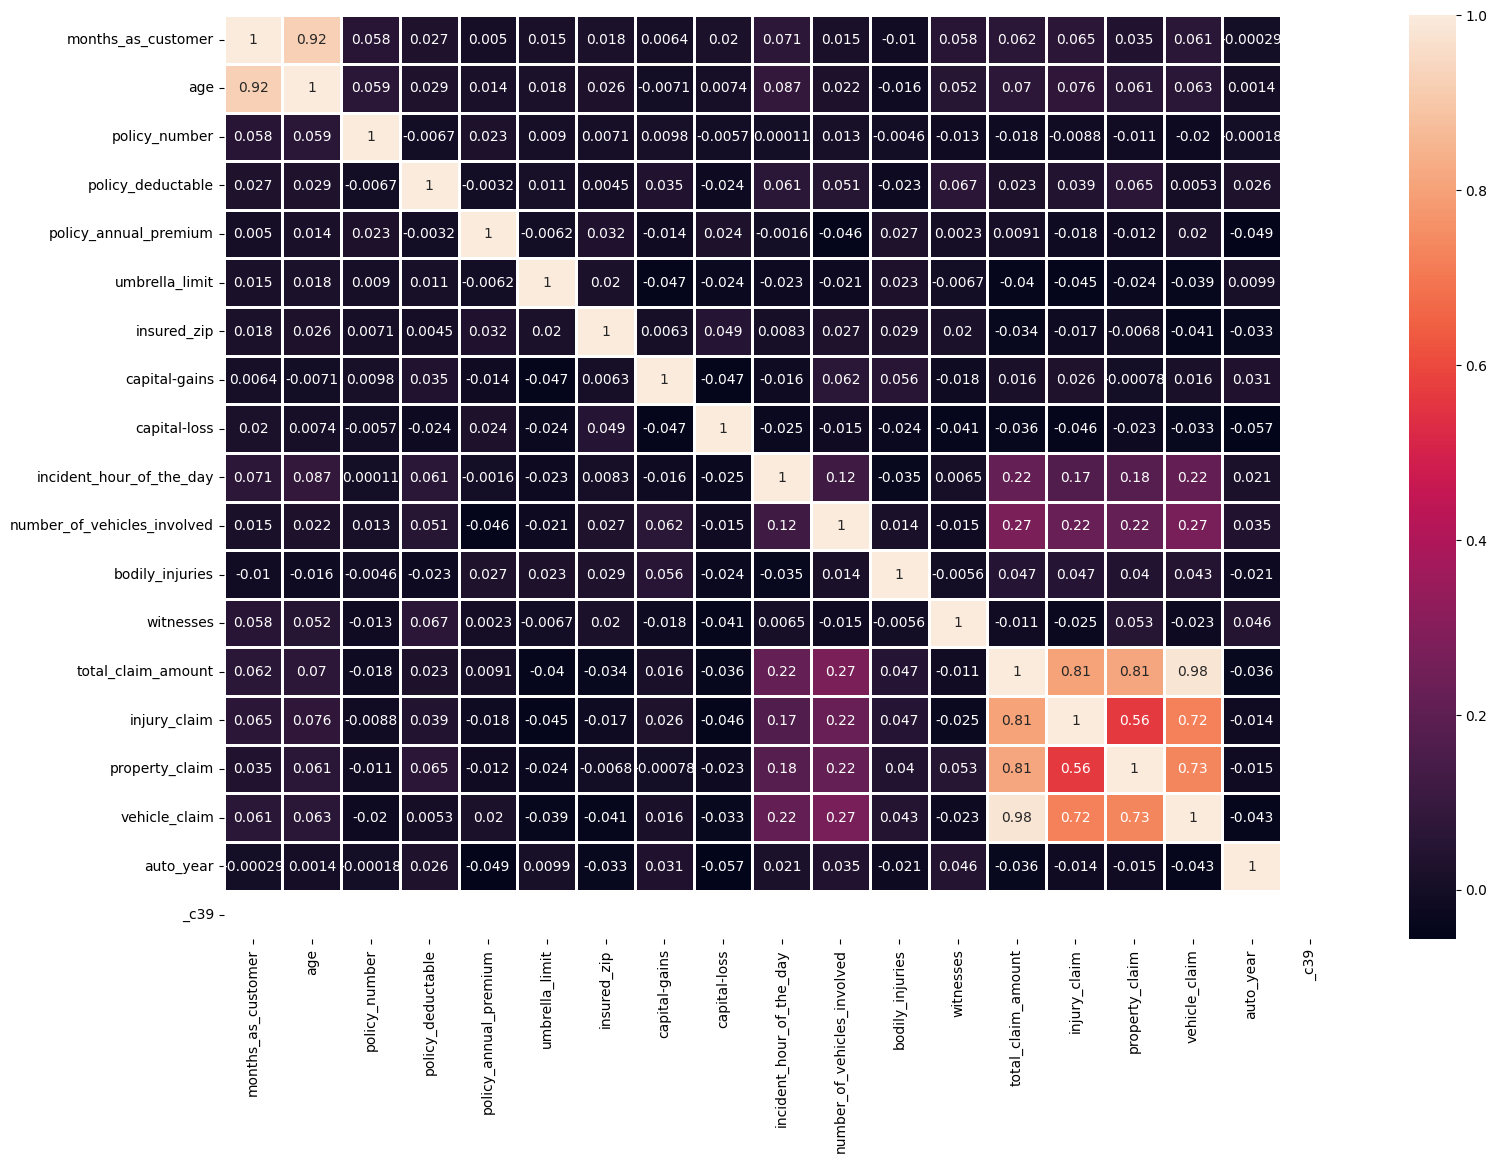

In [14]:
plt.figure(figsize = (18, 12))

corr = df.corr(numeric_only=True)

sns.heatmap(data = corr, annot = True, fmt = '.2g', linewidth = 1)
plt.show()

In [15]:
#remove last column _c39 as the complete column contains null value
df = df.drop(columns=df.columns[-1])
print(df.head(5))

   months_as_customer  age  policy_number policy_bind_date policy_state  \
0                 328   48         521585       2014-10-17           OH   
1                 228   42         342868       2006-06-27           IN   
2                 134   29         687698       2000-09-06           OH   
3                 256   41         227811       1990-05-25           IL   
4                 228   44         367455       2014-06-06           IL   

  policy_csl  policy_deductable  policy_annual_premium  umbrella_limit  \
0    250/500               1000                1406.91               0   
1    250/500               2000                1197.22         5000000   
2    100/300               2000                1413.14         5000000   
3    250/500               2000                1415.74         6000000   
4   500/1000               1000                1583.91         6000000   

   insured_zip  ... witnesses police_report_available total_claim_amount  \
0       466132  ...         

In [16]:
df.nunique()

months_as_customer              391
age                              46
policy_number                  1000
policy_bind_date                951
policy_state                      3
policy_csl                        3
policy_deductable                 3
policy_annual_premium           991
umbrella_limit                   11
insured_zip                     995
insured_sex                       2
insured_education_level           7
insured_occupation               14
insured_hobbies                  20
insured_relationship              6
capital-gains                   338
capital-loss                    354
incident_date                    60
incident_type                     4
collision_type                    3
incident_severity                 4
authorities_contacted             4
incident_state                    7
incident_city                     7
incident_location              1000
incident_hour_of_the_day         24
number_of_vehicles_involved       4
property_damage             

In [17]:
to_drop = ['policy_number','policy_bind_date','policy_state','insured_zip','incident_location','incident_date',
           'incident_state','incident_city','insured_hobbies','auto_make','auto_model','auto_year']

df.drop(to_drop, inplace = True, axis = 1)

In [18]:
X=df.iloc[:,:-1]
Y=df.iloc[:,-1]
print(X.head())
print(Y.head())

   months_as_customer  age policy_csl  policy_deductable  \
0                 328   48    250/500               1000   
1                 228   42    250/500               2000   
2                 134   29    100/300               2000   
3                 256   41    250/500               2000   
4                 228   44   500/1000               1000   

   policy_annual_premium  umbrella_limit insured_sex insured_education_level  \
0                1406.91               0        MALE                      MD   
1                1197.22         5000000        MALE                      MD   
2                1413.14         5000000      FEMALE                     PhD   
3                1415.74         6000000      FEMALE                     PhD   
4                1583.91         6000000        MALE               Associate   

  insured_occupation insured_relationship  ...  incident_hour_of_the_day  \
0       craft-repair              husband  ...                         5   
1  mac

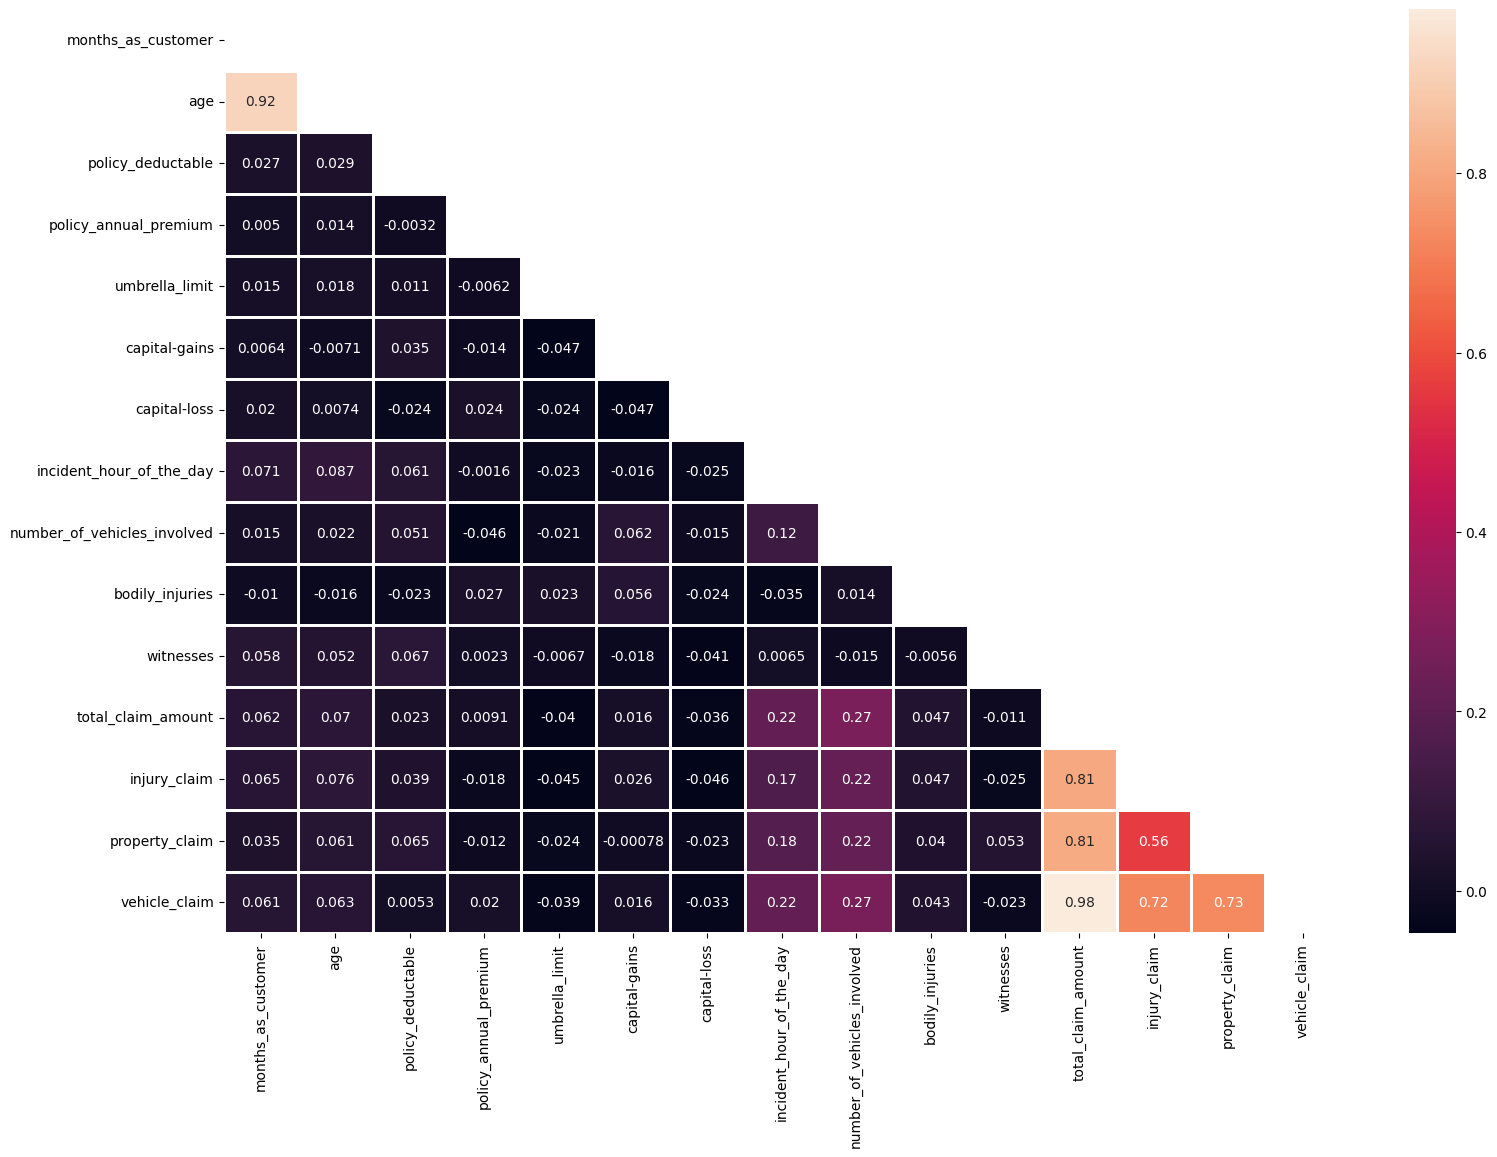

In [19]:
plt.figure(figsize = (18, 12))

corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype = bool))

sns.heatmap(data = corr, mask = mask, annot = True, fmt = '.2g', linewidth = 1)
plt.show()

In [20]:
cat_df = X.select_dtypes(include = ['object'])

In [21]:
cat_df.head()

,policy_csl,insured_sex,insured_education_level,insured_occupation,insured_relationship,incident_type,collision_type,incident_severity,authorities_contacted,property_damage,police_report_available
0,250/500,MALE,MD,craft-repair,husband,Single Vehicle Collision,Side Collision,Major Damage,Police,YES,YES
1,250/500,MALE,MD,machine-op-inspct,other-relative,Vehicle Theft,NaN,Minor Damage,Police,NaN,NaN
2,100/300,FEMALE,PhD,sales,own-child,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NO,NO
3,250/500,FEMALE,PhD,armed-forces,unmarried,Single Vehicle Collision,Front Collision,Major Damage,Police,NaN,NO
4,500/1000,MALE,Associate,sales,unmarried,Vehicle Theft,NaN,Minor Damage,Police,NO,NO


In [22]:
cat_df = pd.get_dummies(cat_df, drop_first = True)

In [23]:
cat_df.head()

,policy_csl_250/500,policy_csl_500/1000,insured_sex_MALE,insured_education_level_College,insured_education_level_High School,insured_education_level_JD,insured_education_level_MD,insured_education_level_Masters,insured_education_level_PhD,insured_occupation_armed-forces,...,collision_type_Rear Collision,collision_type_Side Collision,incident_severity_Minor Damage,incident_severity_Total Loss,incident_severity_Trivial Damage,authorities_contacted_Fire,authorities_contacted_Other,authorities_contacted_Police,property_damage_YES,police_report_available_YES
0,True,False,True,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,True,True,True
1,True,False,True,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,True,False,...,True,False,True,False,False,False,False,True,False,False
3,True,False,False,False,False,False,False,False,True,True,...,False,False,False,False,False,False,False,True,False,False
4,False,True,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False


In [24]:
# extracting the numerical columns

num_df = X.select_dtypes(include = ['int64'])

In [25]:
X = pd.concat([num_df, cat_df], axis = 1)

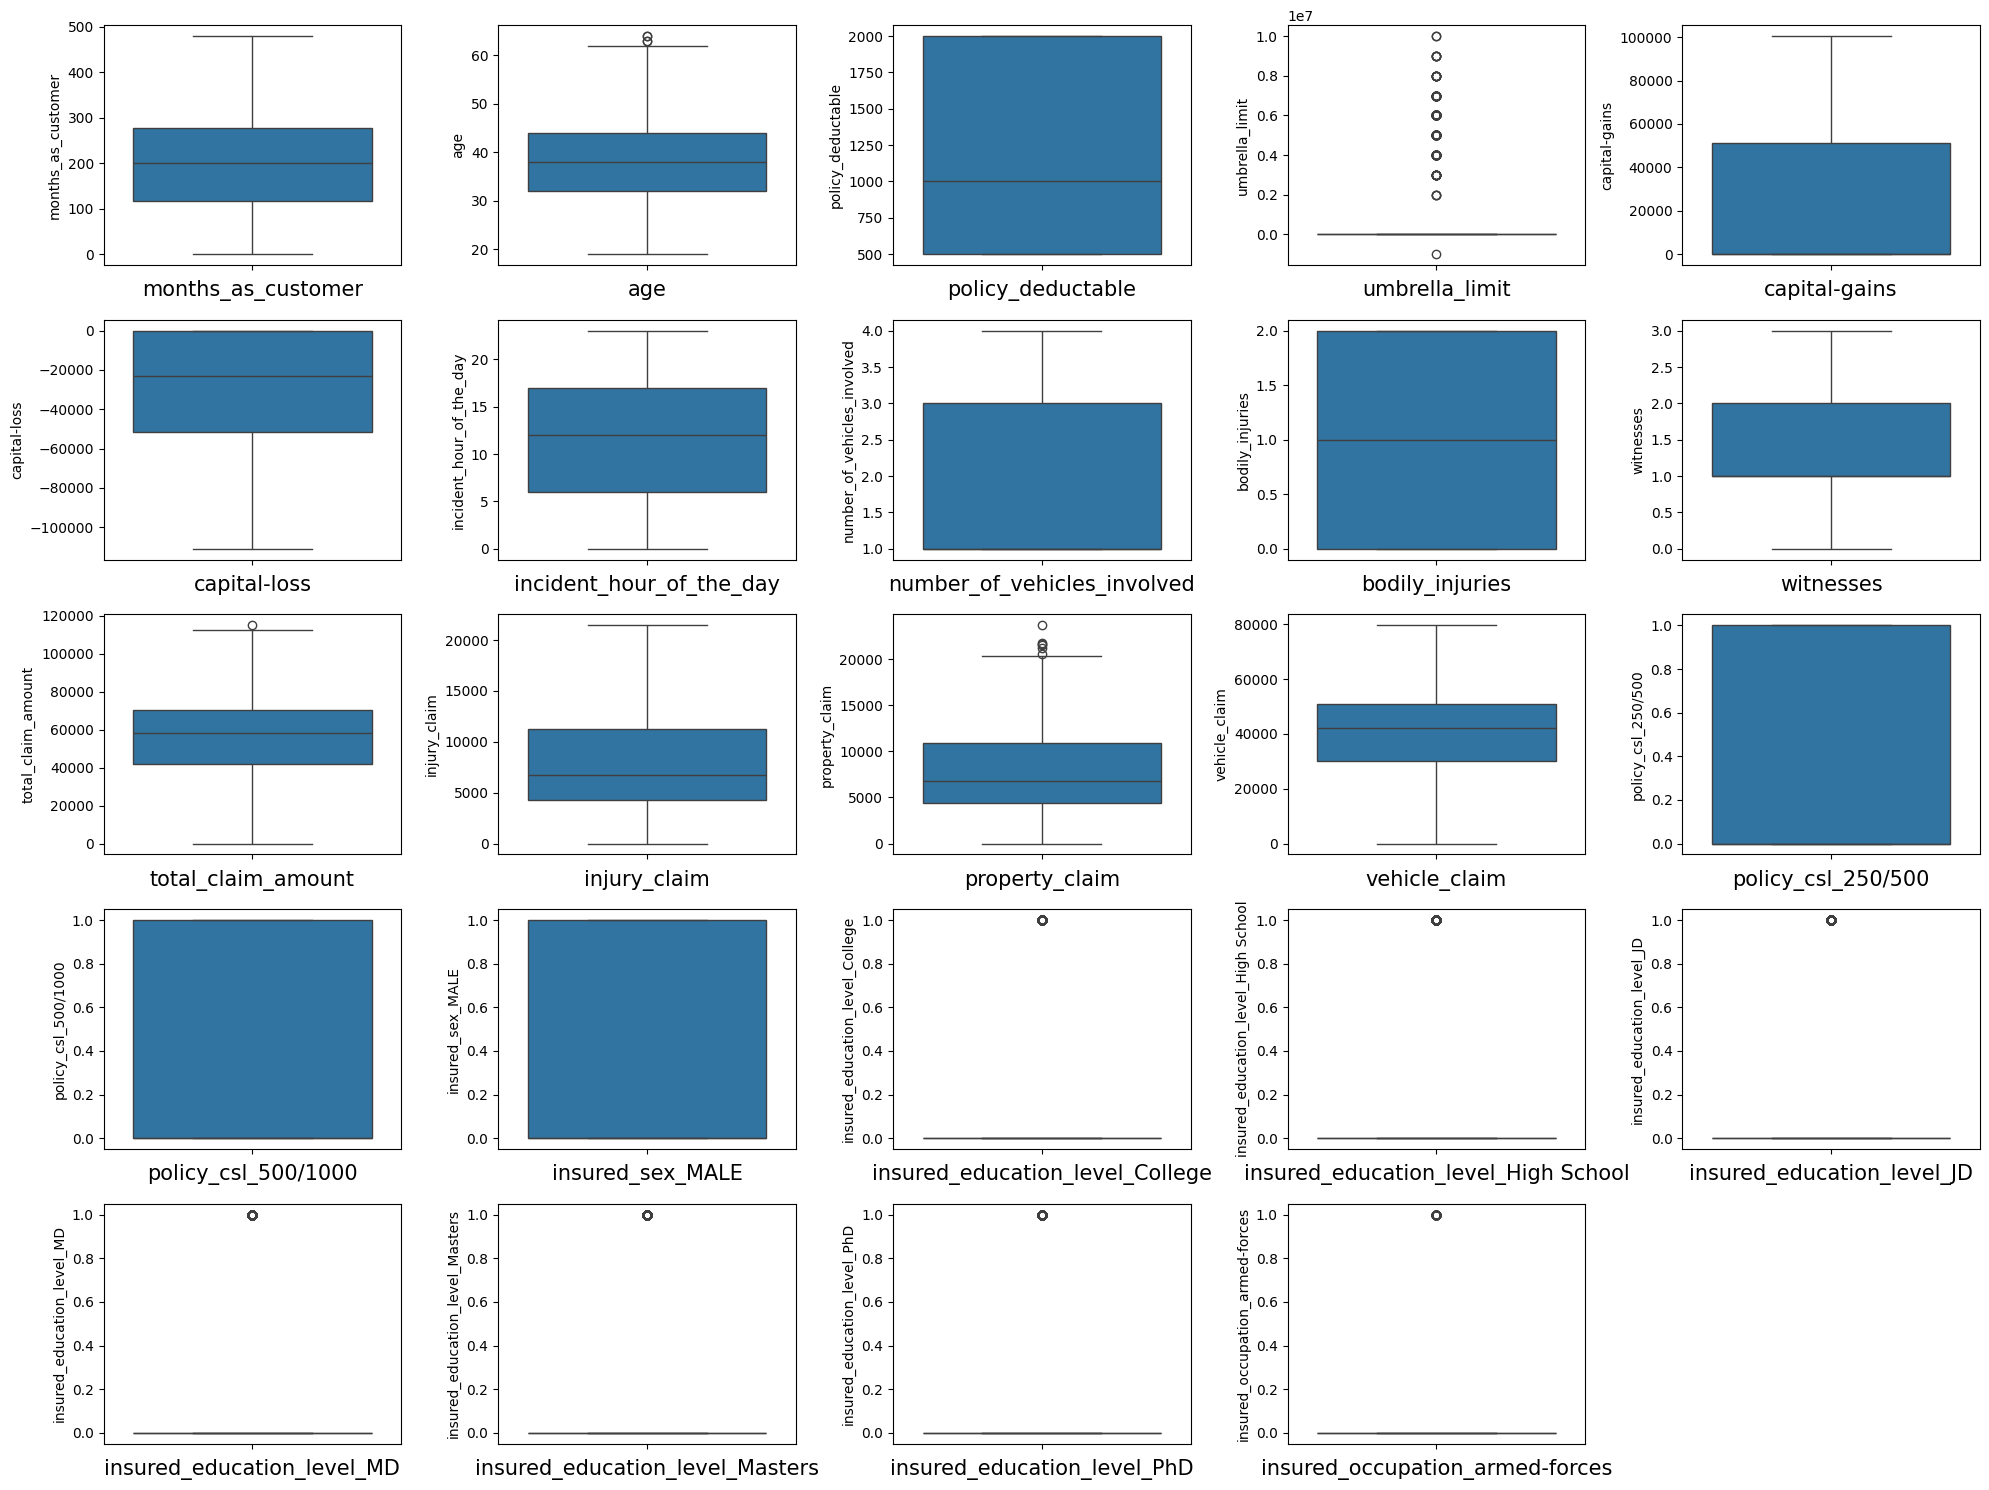

In [26]:
plt.figure(figsize = (20, 15))
plotnumber = 1

for col in X.columns:
    if plotnumber <= 24:
        ax = plt.subplot(5, 5, plotnumber)
        sns.boxplot(X[col])
        plt.xlabel(col, fontsize = 15)

    plotnumber += 1
plt.tight_layout()
plt.show()

In [27]:
#data split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25, random_state=42, stratify=Y)

In [28]:
num_df = X_train[['months_as_customer', 'policy_deductable', 'umbrella_limit',
       'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'injury_claim', 'property_claim',
       'vehicle_claim']]

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_df)

In [30]:
scaled_num_df = pd.DataFrame(data = scaled_data, columns = num_df.columns, index = X_train.index)
scaled_num_df.head()

,months_as_customer,policy_deductable,umbrella_limit,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,injury_claim,property_claim,vehicle_claim
984,-0.354152,-0.242536,-0.477068,1.119126,-0.844190,-1.527215,-0.822818,1.225277,-0.428401,-0.344005,0.822028,-0.179708
118,-0.345414,1.374369,-0.477068,0.707254,0.936435,-1.094712,-0.822818,0.011330,1.366576,2.131495,0.328240,1.313842
656,-0.843440,-1.050988,1.298620,2.072935,0.936435,-0.518042,-0.822818,0.011330,1.366576,-1.337025,-1.428585,-1.818247
169,-1.367677,1.374369,-0.477068,1.830870,0.936435,0.923633,-0.822818,0.011330,-1.325890,-1.359182,-1.371453,-1.681572
427,-0.983236,-0.242536,1.298620,1.404546,0.936435,1.067801,-0.822818,0.011330,-1.325890,-0.138553,-0.134942,0.488077


In [31]:
X_train.drop(columns = scaled_num_df.columns, inplace = True)

In [32]:
X_train = pd.concat([scaled_num_df, X_train], axis = 1)

In [33]:
X_train
X_train.shape

(750, 54)

In [34]:
num_test_df = X_test[['months_as_customer', 'policy_deductable', 'umbrella_limit',
       'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
       'injury_claim', 'property_claim','vehicle_claim']]

scaled_test_data = scaler.transform(num_test_df)

scaled_test_df = pd.DataFrame(data = scaled_test_data,
                              columns = num_test_df.columns,
                              index = X_test.index)

In [35]:
X_test.drop(columns = scaled_test_df.columns, inplace = True)

X_test = pd.concat([scaled_test_df, X_test], axis = 1)

In [36]:
X_test
X_test.shape

(250, 54)

In [37]:
cat_columns = X_train.select_dtypes(include=['object']).columns
num_columns = X_train.select_dtypes(include=['int64','float64']).columns

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_columns),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_columns)
    ]
)

In [39]:
#logistic regression
from sklearn.pipeline import Pipeline
pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]
)
pipe.fit(X_train,Y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
lg_pred=pipe.predict(X_test)
print(confusion_matrix(Y_test,lg_pred))
print(classification_report(Y_test,lg_pred))
print("Logistic Regression Accuracy:",accuracy_score(Y_test,lg_pred))
lg_acc=accuracy_score(Y_test,lg_pred)

[[187   1]
 [ 60   2]]
              precision    recall  f1-score   support

           N       0.76      0.99      0.86       188
           Y       0.67      0.03      0.06        62

    accuracy                           0.76       250
   macro avg       0.71      0.51      0.46       250
weighted avg       0.73      0.76      0.66       250

Logistic Regression Accuracy: 0.756


In [41]:
#KNN
knn_classifier=KNeighborsClassifier(n_neighbors=7, metric="minkowski")
knn_classifier.fit(X_train,Y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [42]:
knn_pred=knn_classifier.predict(X_test)
print(confusion_matrix(Y_test,knn_pred))
print(classification_report(Y_test,knn_pred))
print("KNN Accuracy:",accuracy_score(Y_test,knn_pred))
knn_acc=accuracy_score(Y_test,knn_pred)

[[174  14]
 [ 54   8]]
              precision    recall  f1-score   support

           N       0.76      0.93      0.84       188
           Y       0.36      0.13      0.19        62

    accuracy                           0.73       250
   macro avg       0.56      0.53      0.51       250
weighted avg       0.66      0.73      0.68       250

KNN Accuracy: 0.728


In [43]:
#SVM
svm_classifier = SVC(kernel='rbf', C=10, gamma='scale')
svm_classifier.fit(X_train,Y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [44]:
svm_pred=svm_classifier.predict(X_test)
print(confusion_matrix(Y_test,svm_pred))
print(classification_report(Y_test,svm_pred))
print("SVM Accuracy:",accuracy_score(Y_test,svm_pred))
svm_acc=accuracy_score(Y_test,svm_pred)

[[188   0]
 [ 62   0]]
              precision    recall  f1-score   support

           N       0.75      1.00      0.86       188
           Y       0.00      0.00      0.00        62

    accuracy                           0.75       250
   macro avg       0.38      0.50      0.43       250
weighted avg       0.57      0.75      0.65       250

SVM Accuracy: 0.752


c:\Users\LEGION\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LEGION\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LEGION\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [45]:
#naive Bayes
nb_classifier=GaussianNB()
nb_classifier.fit(X_train,Y_train)


,priors,None
,var_smoothing,1e-09


In [46]:
nb_pred=nb_classifier.predict(X_test)
print(confusion_matrix(Y_test,nb_pred))
print(classification_report(Y_test,nb_pred))
print("Naive Bayes Accuracy:",accuracy_score(Y_test,nb_pred))
nb_acc=accuracy_score(Y_test,nb_pred)

[[158  30]
 [ 41  21]]
              precision    recall  f1-score   support

           N       0.79      0.84      0.82       188
           Y       0.41      0.34      0.37        62

    accuracy                           0.72       250
   macro avg       0.60      0.59      0.59       250
weighted avg       0.70      0.72      0.71       250

Naive Bayes Accuracy: 0.716


In [47]:
#random forest
rf_classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    random_state=1
)
rf_classifier.fit(X_train,Y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
rf_pred=rf_classifier.predict(X_test)
print(confusion_matrix(Y_test,rf_pred))
print(classification_report(Y_test,rf_pred))
print("Random Forest Accuracy:",accuracy_score(Y_test,rf_pred))
rf_acc=accuracy_score(Y_test,rf_pred)

[[178  10]
 [ 55   7]]
              precision    recall  f1-score   support

           N       0.76      0.95      0.85       188
           Y       0.41      0.11      0.18        62

    accuracy                           0.74       250
   macro avg       0.59      0.53      0.51       250
weighted avg       0.68      0.74      0.68       250

Random Forest Accuracy: 0.74


In [49]:
models = pd.DataFrame({
    'Model' : ['SVC', 'KNN', 'Naive Bayes', 'Random Forest','Logistic Regression'],
    'Accuracy' : [svm_acc, knn_acc, nb_acc, rf_acc, lg_acc]
})

models.sort_values(by = 'Accuracy', ascending = False)

,Model,Accuracy
4,Logistic Regression,0.756
0,SVC,0.752
3,Random Forest,0.740
1,KNN,0.728
2,Naive Bayes,0.716


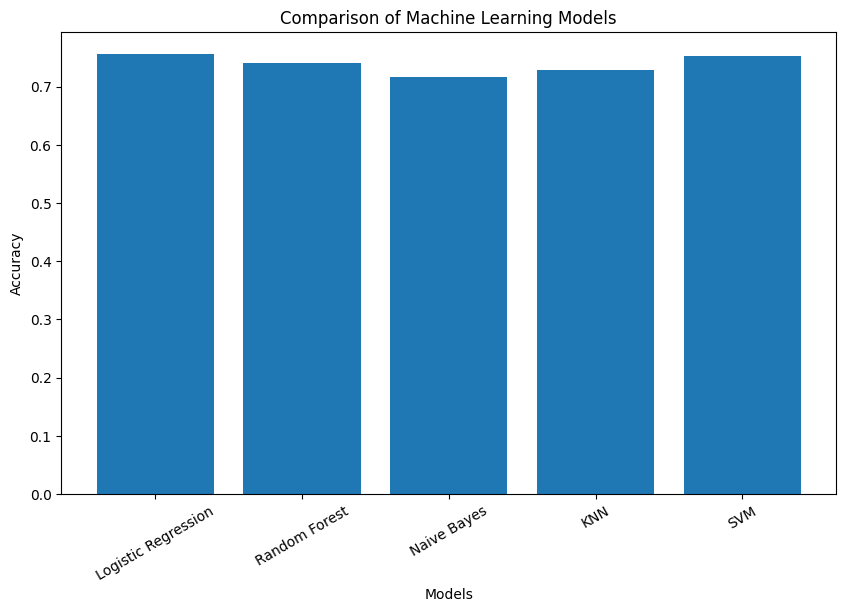

In [51]:
models_bar = {
    "Logistic Regression": pipe,
    "Random Forest": rf_classifier,
    "Naive Bayes": nb_classifier,
    "KNN": knn_classifier,
    "SVM": svm_classifier,

}

accuracies = [lg_acc,rf_acc,nb_acc,knn_acc,svm_acc]

plt.figure(figsize=(10,6))

plt.bar(models_bar.keys(), accuracies)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()


In [52]:
import pickle
pickle.dump(pipe, open("fraud_model.pkl", "wb"))
